# [DRIVE] MATHFI -- AGG FOLD LOOPS -- seed 1337

In [1]:
from pathlib import Path
import torch
torch.cuda.set_device(1)          # pin this kernel to GPU 1
DEVICE = torch.device('cuda:1')

In [2]:
import sys, os
sys.path.append(os.path.abspath('../../'))

print( os.getcwd())
sys.path


c:\Users\s1005\OneDrive\文件\PLM_DOCS\code\githubs\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\notebooks\train_all


['C:\\Users\\s1005\\AppData\\Local\\Programs\\Python\\Python310\\python310.zip',
 'C:\\Users\\s1005\\AppData\\Local\\Programs\\Python\\Python310\\DLLs',
 'C:\\Users\\s1005\\AppData\\Local\\Programs\\Python\\Python310\\lib',
 'C:\\Users\\s1005\\AppData\\Local\\Programs\\Python\\Python310',
 'c:\\Users\\s1005\\OneDrive\\文件\\PLM_DOCS\\code\\githubs\\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\\venv_310_1',
 '',
 'c:\\Users\\s1005\\OneDrive\\文件\\PLM_DOCS\\code\\githubs\\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\\venv_310_1\\lib\\site-packages',
 'c:\\Users\\s1005\\OneDrive\\文件\\PLM_DOCS\\code\\githubs\\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation']

In [3]:
from src.models.unet import UNet
print(UNet)

<class 'src.models.unet.UNet'>


In [4]:
from pathlib import Path
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# CHANGE THESE

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED   = 1337
DATASET = "DRIVE" # "DRIVE" | "STARE" | "CHASEDB1"

PATCH_SIZE = 128
VAL_WINDOW  = PATCH_SIZE
VAL_OVERLAP = 0.25

VESSEL_BIAS=0.7
MIN_PERCENT_VESSEL=0.008
V_MULT=30
DENSE_BIAS=None
BATCH_SIZE=2

IMG_SIZE=512

EPOCHS = 50
warmup_epochs = 5

FOLDS = 10
FOLD_ID = 5

THRESHOLD_EVAL = 0.5


MODEL_NAME = "FR-UNet"
TITLE     = f"[{DATASET}] {MODEL_NAME} NEW SPLIT ({FOLDS} folds) epochs={EPOCHS}"
SAVE_ROOT = Path(f"../../../../pth/{MODEL_NAME}_{DATASET}_NEWSPLIT")     # a clean experiment folder
SAVE_CKPT = SAVE_ROOT / "checkpoints"
SAVE_PRED = SAVE_ROOT / "predictions"   # per-image logits/prob/masks
SAVE_VIZ  = SAVE_ROOT / "visuals"       # PNG overlays per test image
SAVE_LOGS = SAVE_ROOT / "logs"
for d in [SAVE_ROOT, SAVE_CKPT, SAVE_PRED, SAVE_VIZ, SAVE_LOGS]: d.mkdir(parents=True, exist_ok=True)

DATASET_ROOT        = f"../../../../Retinal_Vessel_Segmentation_Datasets/{DATASET}/"
DATASET_LABELFOLDER = "1st_manual"




# IMPORTS

In [6]:
import os, json, math, time, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import LambdaLR
import matplotlib.pyplot as plt

# --- data utils ---
from src.data.splits import (
    split_drive_20_20,
    split_chase_subjectwise_20_8,
    split_stare_leave_one_out,
    stare_loo_fold,
    chase_mc_balanced_splits,
    drive_mc_balanced_splits,

    chase_random_subject_split,

)

from src.data.dataloader import make_loaders
from src.data.augmentations import get_train_augs, get_val_augs

# use YOUR metrics utilities
from src.training.metrics import (
    confusion_counts,
    dice as dice_metric,
    iou as iou_metric,
    roc_auc as roc_auc_metric,
    pr_auc as pr_auc_metric,
    acc_from_counts,
    recall_from_counts,          # sensitivity
    specificity_from_counts,     # specificity
    cldice
)


from src.training.train_cv import (
    sliding_window_forward_logits,
    update_dataset,
    train_one_epoch,
    validate_loss_only,
    atomic_torch_save,
    saveTrainVal
)


# --- evaluation & visualization ---
from src.evaluation.evaluate import evaluate_and_print
from src.evaluation.visualization import visualize_samples

c:\Users\s1005\OneDrive\文件\PLM_DOCS\code\githubs\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\venv_310_1\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# helpers and config

In [7]:
splits, counts = drive_mc_balanced_splits(
    DATASET_ROOT, label_folder=DATASET_LABELFOLDER, n_runs=FOLDS
)

[DRIVE] Run 00 TEST images: ['31_training.png', '27_training.png', '33_training.png', '40_training.png', '35_training.png', '04_test.png', '30_training.png', '20_test.png', '11_test.png', '24_training.png', '38_training.png', '08_test.png', '25_training.png', '19_test.png', '01_test.png', '13_test.png', '14_test.png', '36_training.png', '39_training.png', '06_test.png']
[DRIVE] Run 01 TEST images: ['11_test.png', '28_training.png', '32_training.png', '08_test.png', '02_test.png', '26_training.png', '38_training.png', '29_training.png', '05_test.png', '16_test.png', '25_training.png', '19_test.png', '39_training.png', '03_test.png', '04_test.png', '21_training.png', '12_test.png', '20_test.png', '27_training.png', '23_training.png']
[DRIVE] Run 02 TEST images: ['36_training.png', '10_test.png', '21_training.png', '37_training.png', '23_training.png', '15_test.png', '34_training.png', '09_test.png', '02_test.png', '19_test.png', '16_test.png', '06_test.png', '03_test.png', '20_test.png',

In [8]:
# --- model factory (fresh per fold) ---


def make_model(MODEL_NAME, train_loader = None) -> nn.Module:
    if MODEL_NAME == "MATHFI":
        # --- loss ---
        from src.models.wrappers.dpcn_concat_unet import DPCNConcatUNet
        BASE_KW = {"cbam_reduction": 16}

        if train_loader is not None:
            from src.training.loss_functions import DiceBCEComplementLoss

            def estimate_class_weights(loader, max_batches=20):
                with torch.no_grad():
                    s = 0.0; n = 0
                    for i, b in enumerate(loader):
                        s += b["mask"].float().mean().item(); n += 1
                        if i+1 >= max_batches: break
                p = max(1e-6, min(1-1e-6, s / max(1, n)))
                w1 = 1.0 / p; w0 = 1.0 / (1.0 - p)
                s2 = w0 + w1; w0 = 2.0 * w0 / s2; w1 = 2.0 * w1 / s2
                return w0, w1
            
            w0, w1 = estimate_class_weights(train_loader, max_batches=20)
            loss_fn = DiceBCEComplementLoss(w0=w0, w1=w1, dice_weight=0.5, bce_weight=0.5,
                                        exact_equation=False, reduction="mean")
        
        else: loss_fn = None
        # --- model ---
        return DPCNConcatUNet(
            in_ch=1, enh_channels=64, iters=6,
            threshold_mode="scaled_vat", half_life=2.0,
            reduce_to=64, base_kwargs=BASE_KW
        ).to(DEVICE), loss_fn

    elif MODEL_NAME == "FR-UNet":
        sys.path.append(os.path.abspath('../../../FR-UNet/'))
        loss_fn = nn.BCEWithLogitsLoss()
        from models.fr_unet import FR_UNet
        return FR_UNet().to(DEVICE), loss_fn
        

def add_metrics(model_name, root, label_folder, img_size, ckpt_path, threshold_eval, all_metrics):
        
        
        stem = Path(ckpt_path).stem  # "STARE_fold00"
        fold_id = int(stem.split("fold")[-1])  # 0
        #print(f"checkpoint_path: {ckpt_path}\nfold_id:{fold_id}")

        _, te_pairs, _ = splits[fold_id]
        
        _, test_loader = make_loaders(
            train_pairs=te_pairs, val_pairs=te_pairs,
            image_size=img_size, batch_size=BATCH_SIZE, num_workers=1,
            seed=SEED, strict_fov=True,
            augs_train=None, augs_val=get_val_augs(img_size),
        )

        model, _ = make_model(model_name)
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        model.eval()

        img_stem = f"fold{fold_id:02d}_testset"

        print(
            f"\n== [F{fold_id:02d}] {img_stem} == \n")


        # 6a) metrics
        # 6a) metrics — use YOUR metrics module via our wrapper
        m = evaluate_and_print(model, test_loader, device = DEVICE, threshold=threshold_eval, compute_auc=True)
        m["fold_id"]  = fold_id
        m["image_id"] = img_stem
        all_metrics.append(m)


def visualize_batch(loader, name="Loader", n_max=None):
    import matplotlib.pyplot as plt
    total_shown = 0
    for b_idx, batch in enumerate(loader):
        imgs = batch["image"]
        masks = batch["mask"]
        img_path = batch["image_path"][0]
        for i in range(imgs.size(0)):
            total_shown += 1
            if n_max and total_shown > n_max:
                print(f"\nStopped after showing {n_max} images.")
                return
            fig, axs = plt.subplots(1, 2, figsize=(6, 3))
            axs[0].imshow(imgs[i, 0].cpu(), cmap="gray")
            axs[0].set_title(f"{name} Image {total_shown} • {Path(img_path).name} ")
            axs[1].imshow(masks[i, 0].cpu(), cmap="gray")
            axs[1].set_title(f"{name} Mask {total_shown}")
            for ax in axs: ax.axis("off")
            plt.tight_layout()
            plt.show()



# MAIN RUN

In [9]:
# --- main LOO run ---
def run_drive_experiment(
    model_name,
    root,
    label_folder,
    dataset,
    epochs,
    warmup,
    V_MULT,
    batch_size,
    img_size,
    patch_train,
    patch_size,
    vessel_bias_p,
    threshold_eval,
    folds,
    fold_id,
    chckpnt_paths=None,
    SEED=1337,
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu",
    splits = None
):
    rng = np.random.RandomState(SEED)
    all_metrics = []
    per_image_preds = {}   # img_stem -> dict(prob_path, bin_path, fold_id)

    while fold_id < folds:

        # add checkpoint paths to metric list
        if chckpnt_paths:
            for ckpt in chckpnt_paths:
                add_metrics(model_name,
                            root,
                            label_folder,
                            img_size, ckpt,
                            threshold_eval, all_metrics)
            chckpnt_paths.clear()

        if splits is None:
            splits, counts = drive_mc_balanced_splits(
                DATASET_ROOT, label_folder=DATASET_LABELFOLDER, n_runs=folds
            )

        print(f"\n========== {MODEL_NAME} {DATASET} NEW SPLIT, Fold {fold_id+1}/{folds} ==========")
        print(f"\n\t Chosen test subjects: {splits[fold_id][2]}\n")



        ##########################
        # 2) split dataset
        tr_pairs, te_pairs, _ = splits[fold_id]

        # 2a) carve val deterministically from train
        val_pairs = tr_pairs[-4:]
        tr_pairs_ = tr_pairs[:-4]

        # 3) loaders
        train_loader, val_loader = make_loaders(
            train_pairs=tr_pairs_, val_pairs=val_pairs,
            image_size=img_size, batch_size=batch_size, num_workers=1,
            seed=SEED + fold_id, strict_fov=True,
            augs_train=get_train_augs(img_size),
            augs_val=get_val_augs(img_size),
            patch_train=patch_train, patch_size=patch_size,
            vessel_bias_p=vessel_bias_p, virtual_mult=V_MULT,
        )

        _, test_loader = make_loaders(
            train_pairs=te_pairs, val_pairs=te_pairs,
            image_size=img_size, batch_size=batch_size, num_workers=1,
            seed=SEED, strict_fov=True,
            augs_train=None, augs_val=get_val_augs(img_size),
            patch_train=False
        )


        #visualize_batch(train_loader, "Train")
        #visualize_batch(test_loader, "Test", 10)
        #fold_id+=1
        #continue
        #

        # 4) model & optimizer
        model, loss_fn = make_model(model_name, train_loader)

        optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
        scaler    = torch.amp.GradScaler("cuda", enabled=(DEVICE=="cuda"))
        def lr_lambda(e):
            if e < warmup: return (e+1)/max(1, warmup)
            progress = (e - warmup) / max(1, epochs - warmup)
            return 0.5 * (1 + math.cos(math.pi * progress))
        scheduler = LambdaLR(optimizer, lr_lambda)

        # 5) train with best-val checkpointing
        best_val = float("inf")
        ckpt_path = SAVE_CKPT / f"{DATASET}_fold{fold_id:02d}.pth"

        train_losses, val_losses = [], []

        for ep in range(1, epochs+1):
            update_dataset(train_loader.dataset, ep)
            t0=time.time()
            tr_loss  = train_one_epoch(model, train_loader, optimizer, scaler, loss_fn, DEVICE)
            val_loss = validate_loss_only(model, val_loader, loss_fn, PATCH_SIZE, VAL_OVERLAP, DEVICE)
            scheduler.step()
            print(f"[F{fold_id:02d} E{ep:03d}] train={tr_loss:.4f} val={val_loss:.4f} "
                  f"lr={optimizer.param_groups[0]['lr']:.2e} time={(time.time()-t0):.1f}s")


            train_losses.append(float(tr_loss))
            val_losses.append(float(val_loss))

            if val_loss < best_val:
                best_val = val_loss
                atomic_torch_save(model.state_dict(), ckpt_path)
                print(f"\tCHECKPOINT SAVED: {ckpt_path}")

        save_path = SAVE_VIZ / f"TrainVsVal__fold{fold_id:02d}.png"
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        epochs_val = np.arange(1, len(train_losses) + 1)
        saveTrainVal(epochs_val, fold_id, train_losses, val_losses, save_path, TITLE)


        ####################
        #  6) eval on left-out image using best checkpoint
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        model.eval()


        ####################
        #  6a) metrics + print
        m = evaluate_and_print(model, test_loader, device = DEVICE, threshold=threshold_eval, compute_auc=True)
        m["fold_id"]  = fold_id
        batch = next(iter(test_loader))
        img_path = batch["image_path"][0]
        img_stem = Path(img_path).stem
        m["image_id"] = img_stem
        all_metrics.append(m)

        ###################
        # 6b) visualization
        save_viz_dir = SAVE_VIZ / f"testSet__fold{fold_id:02d}.png"
        visualize_samples(
            model=model,
            dataloader=test_loader,
            n_rows=20,
            device=DEVICE,
            threshold=0.5,
            clamp_pred_with_fov=True,
            figsize_per_row=(12, 3),
            is_save = True,
            save_dir = save_viz_dir
        )
        print(f"\t== Visualization SAVED TO FILE: {save_viz_dir} ==")



        fold_id = fold_id + 1

        # END OF FOLD LOOP



    # 7) aggregate & save CSV
    import csv
    keys = ["fold_id","image_id","SEN","SPE", "CLDICE", "ACC","Dice","IoU","AUC","AP"]
    csv_path = SAVE_LOGS / f"{DATASET}_newSplit_perfold.csv"
    with open(csv_path, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=keys); w.writeheader()
        for row in all_metrics: w.writerow({k: row.get(k, "") for k in keys})

    # mean±std
    def _ms(name):
        arr = np.array([r[name] for r in all_metrics if not np.isnan(r[name])], dtype=float)
        return float(arr.mean()), float(arr.std(ddof=1)) if arr.size > 1 else 0.0
    summary = {k: _ms(k) for k in ["SEN","SPE","CLDICE","ACC","Dice","IoU","AUC","AP"]}
    print(f"\n=== {MODEL_NAME} {DATASET} NEW SPLITS ({FOLDS} folds) — mean ± std ===")
    for k,(mu,sig) in summary.items():
        print(f"{k}: {mu:.4f} ± {sig:.4f}")

    with open(SAVE_LOGS / f"{DATASET}_newSplit_summary.json","w") as f:
        json.dump({k: {"mean": mu, "std": sig} for k,(mu,sig) in summary.items()}, f, indent=2)

    # 8) (optional) gallery index of unbiased predictions
    with open(SAVE_LOGS / f"{DATASET}_newSplit_per_image_preds.json","w") as f:
        json.dump(per_image_preds, f, indent=2)

    return all_metrics, summary


C:\Users\s1005\AppData\Local\Temp\ipykernel_45904\3733670334.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=DE


== [F00] fold00_testset == 

=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.8324
Specificity    : 0.9810
clDice         : 0.8221
Accuracy       : 0.9681
Dice           : 0.8140
IoU            : 0.6866
Precision      : 0.8019
FPR            : 0.0190
FDR            : 0.1981
Dice_thin      : 0.5309
Dice_thick     : 0.6830
ROC_AUC        : 0.9841
PR_AUC         : 0.9027
-- Micro (pooled over all pixels) --
Sensitivity    : 0.8287
Specificity    : 0.9810
F1/Dice        : 0.8148
Accuracy       : 0.9681
IoU            : 0.6875
Precision      : 0.8015
FPR            : 0.0190
FDR            : 0.1985
ROC_AUC        : 0.9831
PR_AUC         : 0.8986


C:\Users\s1005\AppData\Local\Temp\ipykernel_45904\3733670334.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=DE


== [F01] fold01_testset == 

=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.8036
Specificity    : 0.9841
clDice         : 0.8077
Accuracy       : 0.9687
Dice           : 0.8105
IoU            : 0.6825
Precision      : 0.8240
FPR            : 0.0159
FDR            : 0.1760
Dice_thin      : 0.5225
Dice_thick     : 0.6847
ROC_AUC        : 0.9838
PR_AUC         : 0.8992
-- Micro (pooled over all pixels) --
Sensitivity    : 0.8012
Specificity    : 0.9841
F1/Dice        : 0.8116
Accuracy       : 0.9687
IoU            : 0.6830
Precision      : 0.8223
FPR            : 0.0159
FDR            : 0.1777
ROC_AUC        : 0.9829
PR_AUC         : 0.8961


C:\Users\s1005\AppData\Local\Temp\ipykernel_45904\3733670334.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=DE


== [F02] fold02_testset == 

=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.8011
Specificity    : 0.9839
clDice         : 0.8153
Accuracy       : 0.9683
Dice           : 0.8067
IoU            : 0.6774
Precision      : 0.8175
FPR            : 0.0161
FDR            : 0.1825
Dice_thin      : 0.5265
Dice_thick     : 0.6761
ROC_AUC        : 0.9831
PR_AUC         : 0.8940
-- Micro (pooled over all pixels) --
Sensitivity    : 0.7966
Specificity    : 0.9839
F1/Dice        : 0.8071
Accuracy       : 0.9683
IoU            : 0.6766
Precision      : 0.8178
FPR            : 0.0161
FDR            : 0.1822
ROC_AUC        : 0.9825
PR_AUC         : 0.8911


C:\Users\s1005\AppData\Local\Temp\ipykernel_45904\3733670334.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=DE


== [F03] fold03_testset == 

=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.7841
Specificity    : 0.9842
clDice         : 0.7994
Accuracy       : 0.9672
Dice           : 0.7990
IoU            : 0.6663
Precision      : 0.8194
FPR            : 0.0158
FDR            : 0.1806
Dice_thin      : 0.5064
Dice_thick     : 0.6737
ROC_AUC        : 0.9795
PR_AUC         : 0.8850
-- Micro (pooled over all pixels) --
Sensitivity    : 0.7805
Specificity    : 0.9842
F1/Dice        : 0.7989
Accuracy       : 0.9672
IoU            : 0.6652
Precision      : 0.8182
FPR            : 0.0158
FDR            : 0.1818
ROC_AUC        : 0.9792
PR_AUC         : 0.8821


C:\Users\s1005\AppData\Local\Temp\ipykernel_45904\3733670334.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=DE


== [F04] fold04_testset == 

=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.8161
Specificity    : 0.9823
clDice         : 0.8144
Accuracy       : 0.9686
Dice           : 0.8069
IoU            : 0.6770
Precision      : 0.8030
FPR            : 0.0177
FDR            : 0.1970
Dice_thin      : 0.5263
Dice_thick     : 0.6759
ROC_AUC        : 0.9846
PR_AUC         : 0.8944
-- Micro (pooled over all pixels) --
Sensitivity    : 0.8135
Specificity    : 0.9823
F1/Dice        : 0.8076
Accuracy       : 0.9686
IoU            : 0.6773
Precision      : 0.8018
FPR            : 0.0177
FDR            : 0.1982
ROC_AUC        : 0.9840
PR_AUC         : 0.8917
[DRIVE] Run 00 TEST images: ['31_training.png', '27_training.png', '33_training.png', '40_training.png', '35_training.png', '04_test.png', '30_training.png', '20_test.png', '11_test.png', '24_training.png', '38_training.png', '08_test.png', '25_training.png', '19_test.png', '01_test.png', '13_test.png', '14_test.pn

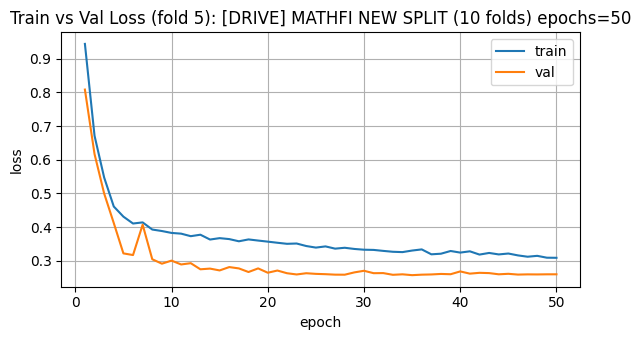

	 TRAIN vs VAL SAVED TO: ..\..\..\..\pth\MATHFI_DRIVE_NEWSPLIT\visuals\TrainVsVal__fold05.png


C:\Users\s1005\AppData\Local\Temp\ipykernel_45904\2827609191.py:126: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=D

=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.8094
Specificity    : 0.9829
clDice         : 0.8148
Accuracy       : 0.9679
Dice           : 0.8085
IoU            : 0.6797
Precision      : 0.8126
FPR            : 0.0171
FDR            : 0.1874
Dice_thin      : 0.5253
Dice_thick     : 0.6775
ROC_AUC        : 0.9817
PR_AUC         : 0.8949
-- Micro (pooled over all pixels) --
Sensitivity    : 0.8061
Specificity    : 0.9829
F1/Dice        : 0.8095
Accuracy       : 0.9679
IoU            : 0.6800
Precision      : 0.8130
FPR            : 0.0171
FDR            : 0.1870
ROC_AUC        : 0.9811
PR_AUC         : 0.8926


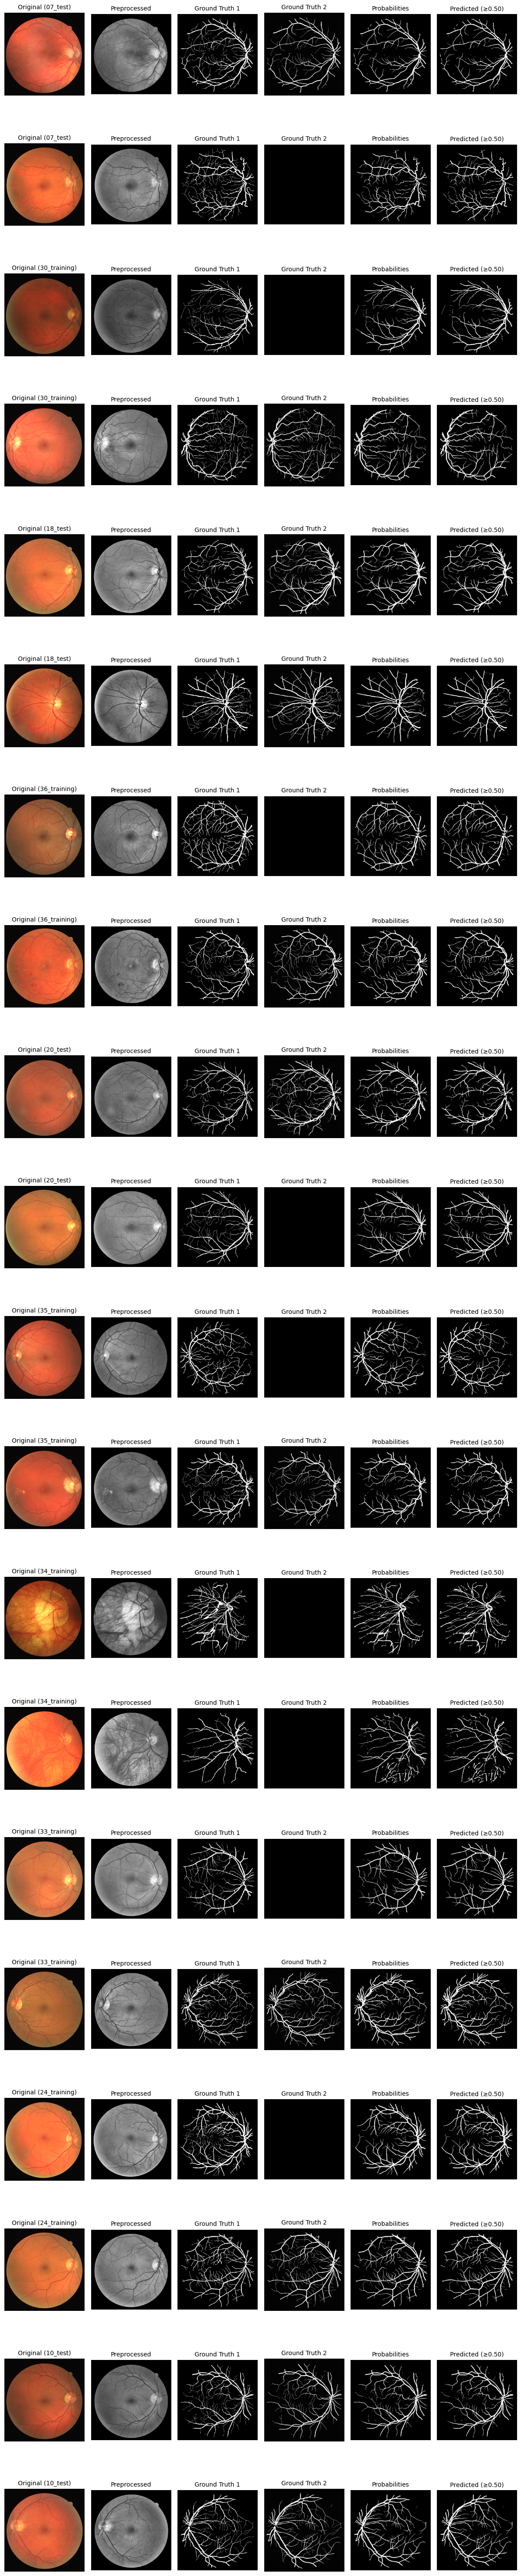

	== Visualization SAVED TO FILE: ..\..\..\..\pth\MATHFI_DRIVE_NEWSPLIT\visuals\testSet__fold05.png ==

========== MATHFI DRIVE NEW SPLIT, Fold 7/10 ==========

	 Chosen test subjects: [3, 1, 11, 7, 12, 28, 21, 37, 24, 8, 9, 16, 20, 4, 30, 2, 32, 29, 0, 34]

[F06 E001] train=1.0452 val=0.8941 lr=1.20e-04 time=48.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_DRIVE_NEWSPLIT\checkpoints\DRIVE_fold06.pth
[F06 E002] train=0.7448 val=0.6884 lr=1.80e-04 time=40.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_DRIVE_NEWSPLIT\checkpoints\DRIVE_fold06.pth
[F06 E003] train=0.5809 val=0.4924 lr=2.40e-04 time=34.2s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_DRIVE_NEWSPLIT\checkpoints\DRIVE_fold06.pth
[F06 E004] train=0.5033 val=0.3702 lr=3.00e-04 time=34.2s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_DRIVE_NEWSPLIT\checkpoints\DRIVE_fold06.pth
[F06 E005] train=0.4596 val=0.3366 lr=3.00e-04 time=32.7s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_DRIVE_NEWSPLIT\checkpoints\DRIVE_fold06.pth
[F06 E006] train=0.437

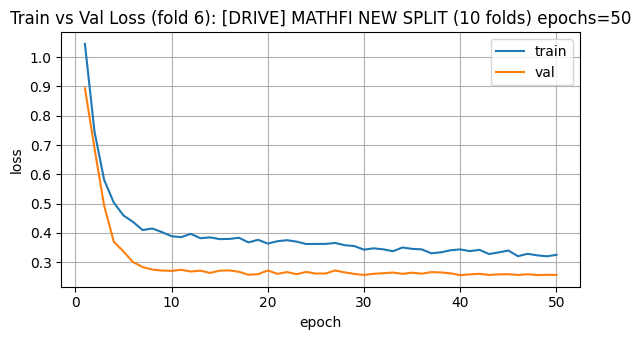

	 TRAIN vs VAL SAVED TO: ..\..\..\..\pth\MATHFI_DRIVE_NEWSPLIT\visuals\TrainVsVal__fold06.png


C:\Users\s1005\AppData\Local\Temp\ipykernel_45904\2827609191.py:126: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=D

=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.7982
Specificity    : 0.9846
clDice         : 0.8016
Accuracy       : 0.9686
Dice           : 0.8090
IoU            : 0.6800
Precision      : 0.8254
FPR            : 0.0154
FDR            : 0.1746
Dice_thin      : 0.5182
Dice_thick     : 0.6857
ROC_AUC        : 0.9830
PR_AUC         : 0.8956
-- Micro (pooled over all pixels) --
Sensitivity    : 0.7958
Specificity    : 0.9845
F1/Dice        : 0.8103
Accuracy       : 0.9686
IoU            : 0.6812
Precision      : 0.8254
FPR            : 0.0155
FDR            : 0.1746
ROC_AUC        : 0.9823
PR_AUC         : 0.8938


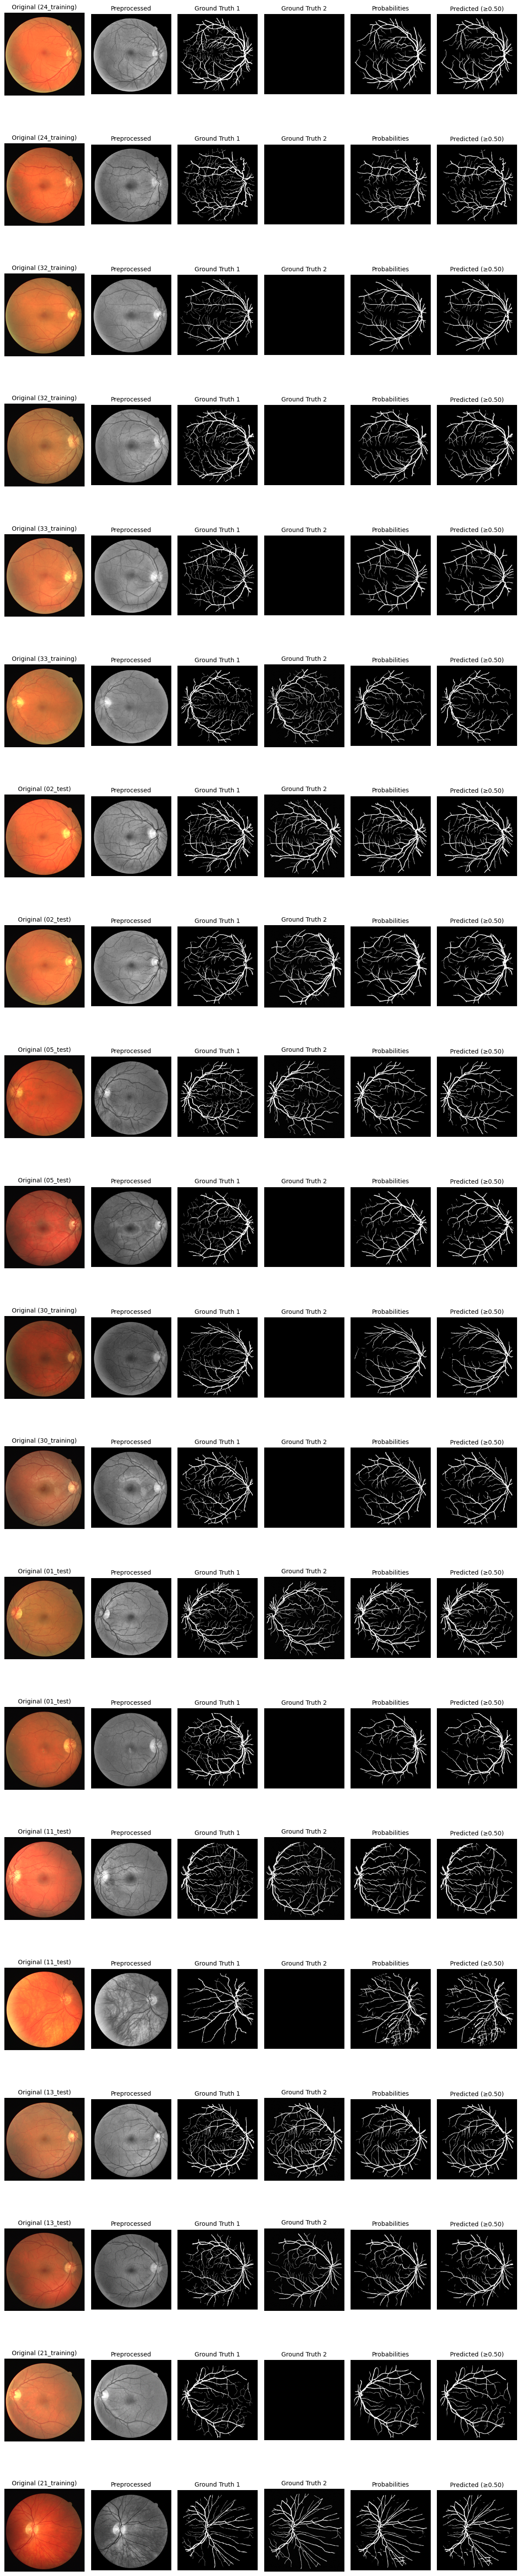

	== Visualization SAVED TO FILE: ..\..\..\..\pth\MATHFI_DRIVE_NEWSPLIT\visuals\testSet__fold06.png ==

========== MATHFI DRIVE NEW SPLIT, Fold 8/10 ==========

	 Chosen test subjects: [13, 31, 14, 23, 6, 34, 10, 29, 22, 36, 20, 0, 3, 38, 18, 5, 26, 24, 19, 35]

[F07 E001] train=0.9540 val=0.8796 lr=1.20e-04 time=32.4s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_DRIVE_NEWSPLIT\checkpoints\DRIVE_fold07.pth
[F07 E002] train=0.6932 val=0.5890 lr=1.80e-04 time=40.8s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_DRIVE_NEWSPLIT\checkpoints\DRIVE_fold07.pth
[F07 E003] train=0.5507 val=0.4366 lr=2.40e-04 time=46.8s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_DRIVE_NEWSPLIT\checkpoints\DRIVE_fold07.pth
[F07 E004] train=0.4687 val=0.3932 lr=3.00e-04 time=47.8s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_DRIVE_NEWSPLIT\checkpoints\DRIVE_fold07.pth


In [ ]:

all_metrics, summary = run_drive_experiment(
    model_name=MODEL_NAME,
    dataset=DATASET,
    V_MULT=V_MULT,
    root=DATASET_ROOT,
    label_folder=DATASET_LABELFOLDER,
    epochs=EPOCHS,
    warmup=warmup_epochs,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    patch_train=True,
    patch_size=PATCH_SIZE,
    vessel_bias_p=VESSEL_BIAS,
    threshold_eval=THRESHOLD_EVAL,
    folds=FOLDS,
    fold_id=FOLD_ID,   #starts at any fold_id

    chckpnt_paths= [
         r"..\..\..\..\pth\MATHFI_DRIVE_NEWSPLIT\checkpoints\DRIVE_fold00.pth",
         r"..\..\..\..\pth\MATHFI_DRIVE_NEWSPLIT\checkpoints\DRIVE_fold01.pth",
         r"..\..\..\..\pth\MATHFI_DRIVE_NEWSPLIT\checkpoints\DRIVE_fold02.pth",
         r"..\..\..\..\pth\MATHFI_DRIVE_NEWSPLIT\checkpoints\DRIVE_fold03.pth",
         r"..\..\..\..\pth\MATHFI_DRIVE_NEWSPLIT\checkpoints\DRIVE_fold04.pth",


         #"..\..\..\..\pth\FR-UNet_STARE_NEWSPLIT\checkpoints\STARE_fold02.pth"

    ]
)

